# Testing algorithm MonomialApproximationVector

Two vector reconstruction of the monomial secret:

1. build a small LEP instance and its secret monomial, represented as two lists instead of the full n x n matrix
2. leak both lists through the bitwise channel
3. reconstruct the monomial approximation with **Algorithm 5** (`compute_vector_posteriors_list_based` + `monomial_approximation_vector`, in `core/LEP_prediction_and_repair_v2.py`) and compare it row-by-row against the true secret.

## Setup

In [71]:
import os
import sys

for _rel in ['../../core', '../core', 'core']:
    if os.path.isdir(_rel):
        sys.path.insert(0, os.path.abspath(_rel))

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
from sage.all import GF, matrix, set_random_seed

from instances_generator import get_random_generator_matrix, obtain_parity_check_matrix
from instances_generator_monomial_as_list import (
    generate_random_monomial_as_lists,
    generate_bit_channel_hint_for_list,
    monomial_lists_to_matrix,
    build_leaked_monomial_matrix,
)
from LEP_prediction_and_repair_v2 import (
    compute_vector_posteriors_list_based,
    monomial_approximation_vector,
    predict_image_from_lists,
    predict_image,
    compute_posterior_table,
    monomial_approximation,
    set_verbose,
)

set_verbose(False)  # flip to True to see progress prints if augmenting n

## Parameters

In [ ]:
n = 12
k = 6
q = 17
alpha = 0.2
beta  = 0.05
seed  = 4

set_random_seed(seed)
F = GF(q)
print(f"n={n}, k={k}, q={q}, alpha={alpha}, beta={beta}, seed={seed}")

n=12, k=6, q=17, alpha=0.200000000000000, beta=0.0500000000000000, seed=4


## Create the instance

In [72]:
G1 = get_random_generator_matrix(n, k, q)

permutation, values = generate_random_monomial_as_lists(n, q, is_permutation=False)
Q = monomial_lists_to_matrix(n, q, permutation, values)
G2 = (G1 * Q).rref()

print("True secret, as two lists:")
print("  permutation:", permutation)
print("  values:     ", values)

True secret, as two lists:
  permutation: [9, 7, 6, 8, 10, 4, 0, 3, 11, 5, 1, 2]
  values:      [2, 15, 9, 13, 12, 11, 15, 14, 16, 11, 16, 6]


## Simulate the leakage

Each list is leaked independently through its own bitwise channel: the permutation list uses `ceil(log2(n))` bits per index, the values list uses `ceil(log2(q))` bits per value. `generate_bit_channel_hint_for_list` flips each bit with probability `alpha` (a 1 -> 0) or `beta` (a 0 -> 1), exactly the channel `compute_vector_posteriors_list_based` assumes.

In [73]:
perm_bit_width = math.ceil(math.log2(n))
val_bit_width = math.ceil(math.log2(q))

noisy_permutation = generate_bit_channel_hint_for_list(permutation, alpha, beta, bit_width=perm_bit_width)
noisy_values = generate_bit_channel_hint_for_list(values, alpha, beta, bit_width=val_bit_width)

print(f"{'row':>4} {'true pi':>8} {'leaked pi':>10} {'true d':>7} {'leaked d':>9}   flipped?")
for i in range(n):
    pi_flip = (noisy_permutation[i] % n) != permutation[i]
    d_flip = (noisy_values[i] % q) != values[i]
    flag = ('pi ' if pi_flip else '   ') + ('d' if d_flip else ' ')
    print(f"{i:>4} {int(permutation[i]):>8} {int(noisy_permutation[i]):>10} {int(values[i]):>7} {int(noisy_values[i]):>9}   {flag}")

 row  true pi  leaked pi  true d  leaked d   flipped?
   0        9          1       2         2   pi  
   1        7          3      15        12   pi d
   2        6          6       9         9       
   3        8          8      13        13       
   4       10         10      12        12       
   5        4          5      11        10   pi d
   6        0          0      15        15       
   7        3          2      14        14   pi  
   8       11          3      16         0   pi d
   9        5          5      11         3      d
  10        1          1      16        16       
  11        2          2       6         2      d


## Run MonomialApproximationVector

`compute_vector_posteriors_list_based` turns the two leaked lists into the per-row posteriors `p_i^perm(j)` and `p_i^scale(a)` Algorithm 5 expects as input; `monomial_approximation_vector` then runs Algorithm 5's three phases (independent scalar argmax, Hungarian assignment on the permutation posteriors, matrix assembly).

In [74]:
p_perm, p_scale = compute_vector_posteriors_list_based(
    noisy_permutation, noisy_values, n, q, alpha, beta, is_permutation=False,
)

Q_hat, S_perm, d_hat, pi_hat = monomial_approximation_vector(p_perm, p_scale, F)

print("Reconstructed pi_hat:", [int(i) for i in pi_hat])
print("True permutation:    ", permutation)
print()
print("Reconstructed d_hat: ", d_hat)
print("True values:         ", values)

Reconstructed pi_hat: [1, 3, 6, 8, 10, 5, 0, 2, 11, 7, 9, 4]
True permutation:     [9, 7, 6, 8, 10, 4, 0, 3, 11, 5, 1, 2]

Reconstructed d_hat:  [2, 12, 9, 13, 12, 10, 15, 14, 1, 3, 16, 2]
True values:          [2, 15, 9, 13, 12, 11, 15, 14, 16, 11, 16, 6]


## Compare against the naive "matrix straight from the vectors" construction

This section isn't part of the original ask, but follows directly from it: instead of keeping full per-row posteriors, `build_leaked_monomial_matrix` scatters each row's single leaked value straight into the column its leaked index happens to land on. Since the leaked indices aren't a genuine permutation anymore, some columns end up hit twice and others not at all. Feeding that matrix through the *original* whole-matrix pipeline (`compute_posterior_table` + `monomial_approximation`, Algorithm 6) still returns a valid monomial matrix (Hungarian assignment forces a bijection regardless of the input), but on the *same* leaked data, since `compute_posterior_table` assumes per-entry bit-flip noise rather than this scatter/collision noise.

In [77]:
print("Real Q")
print(Q)
naive_hint = build_leaked_monomial_matrix(n, q, noisy_permutation, noisy_values)
print("Naive hint")
print(naive_hint)
zero_cols_naive = [j for j in range(n) if all(naive_hint[i][j] == 0 for i in range(n))]
print("Naive scattered hint matrix - all-zero columns:", zero_cols_naive)

posterior_table_naive = compute_posterior_table(naive_hint, alpha, beta, is_permutation=False)
Q_hat_naive, S_naive, D_loc_naive, pi_naive = monomial_approximation(posterior_table_naive, F)

rows_correct_naive = sum(1 for i in range(n) if list(Q_hat_naive[i]) == list(Q[i]))
print(f"Rows correct (naive matrix -> Algorithm 6 pipeline): {rows_correct_naive} / {n}")
print(f"Rows correct (Algorithm 5, direct from the two vectors): {n_correct} / {n}")
print("Q_hat from naive reconstruction")
print(Q_hat_naive)
print("Q_hat from lists pipeline")
print(Q_hat)

Real Q
[ 0  0  0  0  0  0  0  0  0  2  0  0]
[ 0  0  0  0  0  0  0 15  0  0  0  0]
[ 0  0  0  0  0  0  9  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0 13  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0 12  0]
[ 0  0  0  0 11  0  0  0  0  0  0  0]
[15  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0 14  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0 16]
[ 0  0  0  0  0 11  0  0  0  0  0  0]
[ 0 16  0  0  0  0  0  0  0  0  0  0]
[ 0  0  6  0  0  0  0  0  0  0  0  0]
Naive hint
[ 0  2  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0 12  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  9  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0 13  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0 12  0]
[ 0  0  0  0  0 10  0  0  0  0  0  0]
[15  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0 14  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  3  0  0  0  0  0  0]
[ 0 16  0  0  0  0  0  0  0  0  0  0]
[ 0  0  2  0  0  0  0  0  0  0  0  0]
Naive scattered hint matrix - all-zero columns: [4, 7, 9, 11]
Rows cor

## Accuracy vs. noise level

Sweeps `alpha` and `beta` independently over a small grid, averages a handful of seeds at each `(alpha, beta)` pair and plots Algorithm 5's row-accuracy as a heatmap over the two noise parameters. `n` and `q` stay like the ones set in Section 1.

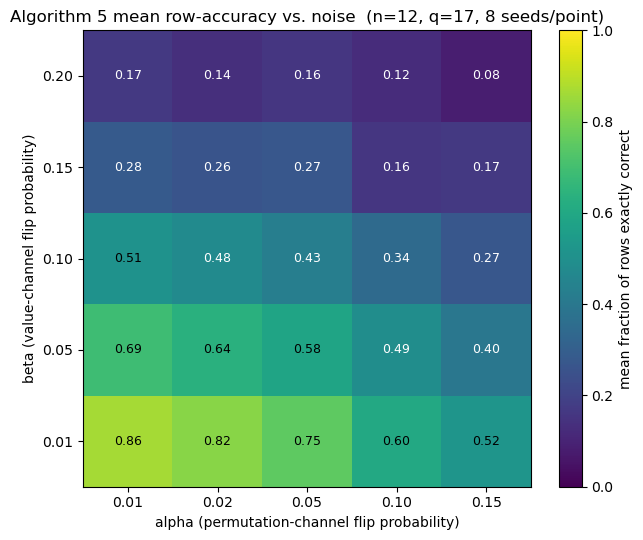

In [70]:
def algorithm5_row_accuracy(n, q, alpha, beta, run_seed):
    set_random_seed(run_seed)
    F_ = GF(q)
    perm, vals = generate_random_monomial_as_lists(n, q, is_permutation=False)
    pbw = math.ceil(math.log2(n))
    vbw = math.ceil(math.log2(q))
    np_ = generate_bit_channel_hint_for_list(perm, alpha, beta, bit_width=pbw)
    nv_ = generate_bit_channel_hint_for_list(vals, alpha, beta, bit_width=vbw)
    pp, ps = compute_vector_posteriors_list_based(np_, nv_, n, q, alpha, beta, is_permutation=False)
    _, _, dh, ph = monomial_approximation_vector(pp, ps, F_)
    correct = sum(1 for i in range(n) if ph[i] == perm[i] and dh[i] == vals[i])
    return float(correct) / int(n)  # plain Python float - Sage Integer/Integer division would give a Rational

alphas_to_try = [0.01, 0.02, 0.05, 0.1, 0.15]
betas_to_try = [0.01, 0.05, 0.1, 0.15, 0.2]
seeds_per_point = range(seed, seed + 8)  # average 8 seeds per (alpha, beta) pair for a smoother heatmap
n_seeds = len(list(seeds_per_point))

accuracy_grid = np.zeros((len(betas_to_try), len(alphas_to_try)))
for bi, b in enumerate(betas_to_try):
    for ai, a in enumerate(alphas_to_try):
        point_accuracies = [algorithm5_row_accuracy(n, q, a, b, s) for s in seeds_per_point]
        accuracy_grid[bi, ai] = float(sum(point_accuracies)) / n_seeds

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(accuracy_grid, origin='lower', cmap='viridis', vmin=0.0, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(alphas_to_try)))
ax.set_xticklabels([f"{a:.2f}" for a in alphas_to_try])
ax.set_yticks(range(len(betas_to_try)))
ax.set_yticklabels([f"{b:.2f}" for b in betas_to_try])
ax.set_xlabel("alpha (permutation-channel flip probability)")
ax.set_ylabel("beta (value-channel flip probability)")
ax.set_title(f"Algorithm 5 mean row-accuracy vs. noise  (n={n}, q={q}, {n_seeds} seeds/point)")

for bi in range(len(betas_to_try)):
    for ai in range(len(alphas_to_try)):
        val = accuracy_grid[bi, ai]
        ax.text(ai, bi, f"{val:.2f}", ha="center", va="center",
                 color="white" if val < 0.5 else "black", fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("mean fraction of rows exactly correct")
plt.tight_layout()
plt.show()